In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import spectral.io.envi as envi
from pathlib import Path
from tqdm.notebook import tqdm

DATA = Path("../data/complex_facility/Images")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")

device: cuda


In [ ]:
all_hdrs = sorted(DATA.glob("MakoSpectrometer-*.img.hdr"))
print(f"{len(all_hdrs)} views found")

wavelengths = np.array(envi.open(all_hdrs[0]).bands.centers)
print(wavelengths.shape)

pixels_list = []
for hdr in tqdm(all_hdrs, desc="loading"):
    cube = np.asarray(envi.open(hdr).load())
    # the autoencoder operates at pixel level, so every pixel is an independent data point
    pixels_list.append(cube.reshape(-1, cube.shape[-1]))

pixels = np.concatenate(pixels_list, axis=0).astype(np.float32)  # (N, 128)
pixels -= pixels.min()
pixels /= pixels.max()
print(f"pixel bank: {pixels.shape}")

231 views found
(128,)


loading:   0%|          | 0/231 [00:00<?, ?it/s]

pixel bank: (3784704, 128)


In [12]:
rng = np.random.default_rng(0)
MAX_PIXELS_TRAIN = 50000

all_idx = np.arange(len(pixels))
rng.shuffle(all_idx)

pixels_train = pixels[all_idx[:MAX_PIXELS_TRAIN]]
pixels_test = pixels[all_idx[MAX_PIXELS_TRAIN : MAX_PIXELS_TRAIN + 10000]]

loader = DataLoader(
    TensorDataset(torch.tensor(pixels_train)),
    batch_size=512,
    shuffle=True,
)
print(f"train: {len(pixels_train):,}   test: {len(pixels_test):,}")

train: 50,000   test: 10,000


In [13]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(1, channels // reduction)),
            nn.ReLU(inplace=True),
            nn.Linear(max(1, channels // reduction), channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        squeeze = x.mean(2)  # squeeze = global avg over spectral length
        scale = self.fc(squeeze)  # excitiation
        return x * scale.unsqueeze(2)  # scale and combine


class ConvSE(nn.Module):
    def __init__(self, in_ch, out_ch, kernel):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.se = SEBlock(out_ch)

    def forward(self, x):
        return self.se(self.conv(x))


class SpectralAE(nn.Module):
    def __init__(self, n_bands=128, latent_dim=32):
        super().__init__()
        self.n_bands = n_bands
        self.latent_dim = latent_dim
        self.enc_len = n_bands // 4  # 2 pool ops

        self.encoder = nn.Sequential(
            ConvSE(1, 32, 7),
            nn.MaxPool1d(2),
            ConvSE(32, 64, 5),
            nn.MaxPool1d(2),
            ConvSE(64, 64, 3),
        )
        self.enc_fc = nn.Linear(64 * self.enc_len, latent_dim)

        self.dec_fc = nn.Linear(latent_dim, 64 * self.enc_len)
        self.decoder = nn.Sequential(
            ConvSE(64, 64, 3),
            nn.Upsample(scale_factor=2),
            ConvSE(64, 32, 5),
            nn.Upsample(scale_factor=2),
            nn.Conv1d(32, 1, 7, padding=3),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x.unsqueeze(1)).flatten(1)
        return self.enc_fc(h)

    def decode(self, z):
        h = F.relu(self.dec_fc(z)).view(z.size(0), 64, self.enc_len)
        return self.decoder(h)[:, 0, : self.n_bands]

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

In [15]:
model = SpectralAE(n_bands=128, latent_dim=32).to(DEVICE)

EPOCHS = 50
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

losses = []
model.train()
for epoch in tqdm(range(EPOCHS), desc="training"):
    ep_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(DEVICE)
        recon, _ = model(batch)
        loss = F.huber_loss(recon, batch)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        ep_loss += loss.item()
    losses.append(ep_loss / len(loader))
    scheduler.step()

model.eval()
print(f"final loss: {losses[-1]:.5f}")

training:   0%|          | 0/50 [00:00<?, ?it/s]

final loss: 0.00000


test loss: 0.000003  |  train loss: 0.000003


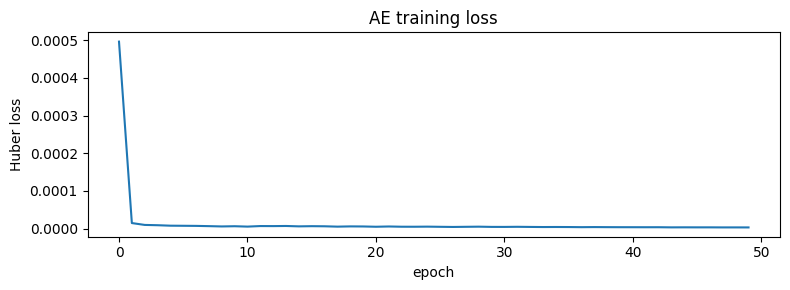

In [25]:
test_tensor = torch.tensor(pixels_test).to(DEVICE)
with torch.no_grad():
    test_recon_all, _ = model(test_tensor)
test_loss = F.huber_loss(test_recon_all, test_tensor)
print(f"test loss: {test_loss.item():.6f}  |  train loss: {losses[-1]:.6f}")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("Huber loss")
plt.title("AE training loss")
plt.tight_layout()
plt.show()

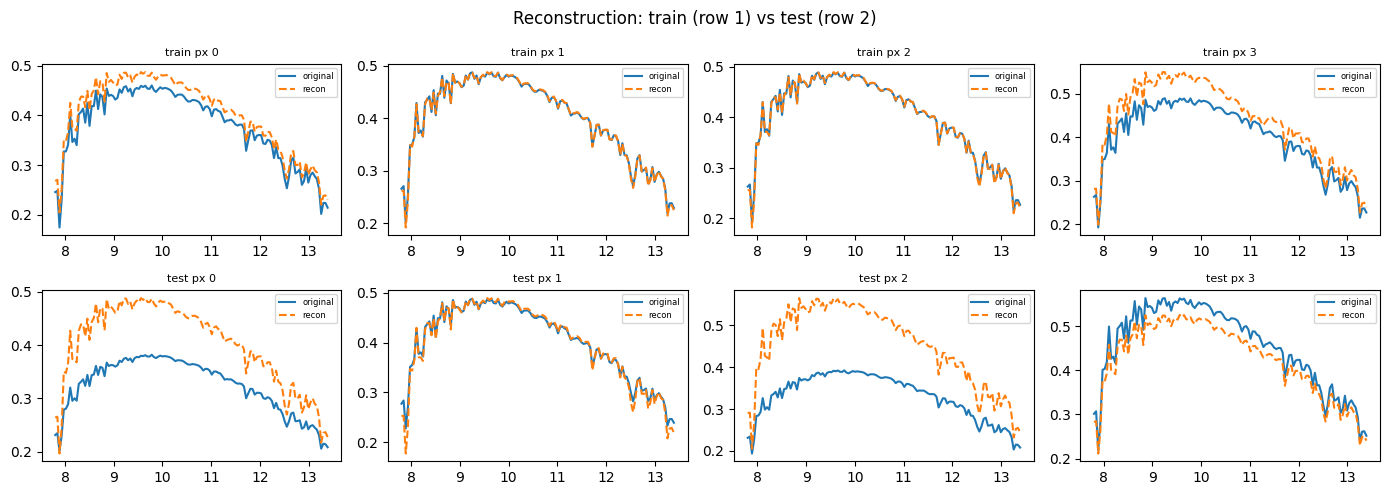

In [32]:
train_idx = rng.choice(len(pixels_train), 4, replace=False)
test_idx = rng.choice(len(pixels_test), 4, replace=False)

train_sample = torch.tensor(pixels_train[train_idx]).to(DEVICE)
with torch.no_grad():
    train_recon, _ = model(train_sample)
train_recon = train_recon.cpu().numpy()

test_sample = torch.tensor(pixels_test[test_idx]).to(DEVICE)
with torch.no_grad():
    test_recon, _ = model(test_sample)
test_recon = test_recon.cpu().numpy()

fig, axes = plt.subplots(2, 4, figsize=(14, 5))

for i in range(4):
    axes[0, i].plot(wavelengths, pixels_train[i], lw=1.5, label="original")
    axes[0, i].plot(wavelengths, train_recon[i], lw=1.5, ls="--", label="recon")
    axes[0, i].set_title(f"train px {i}", fontsize=8)
    axes[0, i].legend(fontsize=6)

    axes[1, i].plot(wavelengths, pixels_test[i], lw=1.5, label="original")
    axes[1, i].plot(wavelengths, test_recon[i], lw=1.5, ls="--", label="recon")
    axes[1, i].set_title(f"test px {i}", fontsize=8)
    axes[1, i].legend(fontsize=6)

plt.suptitle("Reconstruction: train (row 1) vs test (row 2)")
plt.tight_layout()
plt.show()